<center> </center>

<center><font size=5 face="Helvetica" color=#306998><b>
Matrices, Images and Coordinates in Numpy
</b></font></center>

<center><font face="Helvetica" size=3><b>Ang Chen</b></font></center>
<center><font face="Helvetica" size=3>March, 2026</font></center>

***

# Import libraries

In [59]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

# load MATLAB colormap: parula
mat = scipy.io.loadmat("parula.mat")
parula_rgb = mat["P"]
parula_map = ListedColormap(parula_rgb)

plt.rcParams["font.family"] = "Helvetica"
# rc('text', usetex=True)
%matplotlib inline
%config InlineBackend.figure_format = 'svg'


# A simple 2x2 matrix test

In [60]:
A = np.array([[1,2],[3,4]])

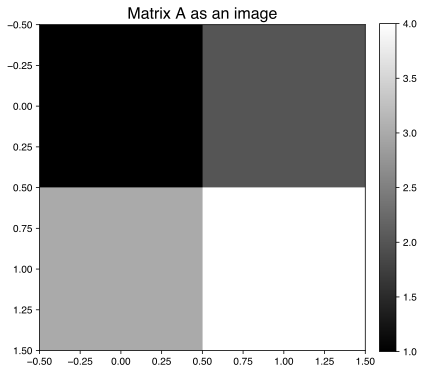

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
im = ax.imshow(A, cmap="gray")
ax.set_aspect("equal")
ax.set_title("Matrix A as an image", fontsize=16)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)   
fig.tight_layout()
plt.show()

# Pupil coordinates in k space

In [62]:
num = 2**8-1

In [63]:
kx = np.linspace(-1, 1, num=num)
ky = np.linspace(1, -1, num=num)

X, Y = np.meshgrid(kx, ky)

In [64]:
field_factor = 1
num_ex, num_ey = num*field_factor, num*field_factor
lda = 0.500
lx, ly = num_ex*lda/2, num_ey*lda/2
dx, dy = lx/num_ex, ly/num_ey

x = np.arange(num_ex)*dx
y = np.arange(num_ey)*dy
X, Y = np.meshgrid(x, y)

In [65]:
k0 = 2*np.pi/lda
amp_0, amp_p1, amp_n1 = 0.8, 0.75, 0.5
kx0, ky0 = 0.2*k0, 0.1*k0
kx_p1, ky_p1 = kx0 + 0.5*k0, ky0
kx_n1, ky_n1 = kx0 - 0.5*k0, ky0

In [66]:
field_total = amp_0*np.exp(1j*(kx0*X+ky0*Y))  + amp_p1*np.exp(1j*(kx_p1*X+ky_p1*Y)) + amp_n1*np.exp(1j*(kx_n1*X+ky_n1*Y)) 
field_intensity = np.abs(field_total) ** 2

In [67]:
pupil_fft = np.fft.fftshift(np.fft.fft2(field_total)) / (num_ex * num_ey)
pupil_intensity = np.flipud(np.abs(pupil_fft))**2
pupil_intensity_max = max(amp_0**2, amp_p1**2, amp_n1**2)

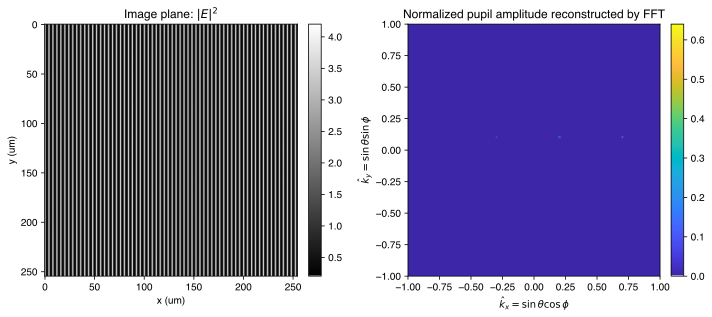

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(5 * 2, 4.5))
im0 = ax[0].imshow(
    field_intensity ,  # add a small constant to avoid log(0)
    # extent=[0, lx, 0, ly],
    aspect="auto",
    cmap="gray",
)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title(r"Image plane: $|E|^2$")

im1 = ax[1].imshow(
    pupil_intensity,
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    vmin=0,
    vmax=pupil_intensity_max,
)
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
ax[1].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[1].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[1].set_title("Normalized pupil amplitude reconstructed by FFT")

fig.tight_layout()